Datensammlung startet...
Datenaufnahme beendet.
     AccX  AccY   AccZ  GyroX  GyroY  GyroZ
0    0.25 -0.75  12.40  -0.11   0.06  -0.01
1    0.17 -0.80  12.42  -0.10   0.05  -0.01
2    0.22 -0.79  12.37  -0.11   0.06  -0.01
3    0.22 -0.78  12.45  -0.10   0.05  -0.01
4    0.26 -0.80  12.40  -0.11   0.06  -0.01
..    ...   ...    ...    ...    ...    ...
293  0.27 -0.77  12.53  -0.10   0.05  -0.01
294  0.23 -0.78  12.37  -0.10   0.06  -0.01
295  0.28 -0.82  12.46  -0.10   0.05  -0.01
296  0.30 -0.78  12.39  -0.10   0.06  -0.01
297  0.19 -0.75  12.45  -0.10   0.05  -0.01

[298 rows x 6 columns]
   AccX  AccY   AccZ  GyroX  GyroY  GyroZ    mean_x     std_x  max_x  min_x  \
0  0.25 -0.75  12.40  -0.11   0.06  -0.01  0.240000  0.034039   0.32   0.17   
1  0.17 -0.80  12.42  -0.10   0.05  -0.01  0.231000  0.059035   0.46   0.12   
2  0.22 -0.79  12.37  -0.11   0.06  -0.01  0.236000  0.038020   0.34   0.14   
3  0.22 -0.78  12.45  -0.10   0.05  -0.01  0.235000  0.039719   0.30   0.13   
4  0.

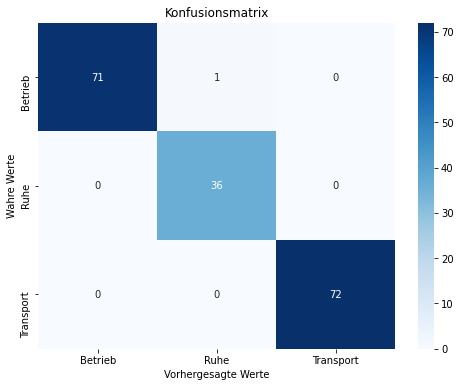

Modell und Scaler wurden gespeichert.
Die vorhergesagte Klasse für die neuen Daten ist: Ruhe


In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np
import serial
import pandas as pd
import time
import pandas as pd
import numpy as np


# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Initialisierung
data = []
start_time = time.time()
duration = 30  # Dauer der Datensammlung in Sekunden

print("Datensammlung startet...")

# 3. Datensammlung
while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 4. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 5. Daten in einen DataFrame umwandeln und speichern
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]  # Spaltennamen ohne Zustand
df = pd.DataFrame(data, columns=columns)
df.to_csv("new_data_example.csv", index=False)
#print("Daten gespeichert in new_data_example.csv")

# Optional: Daten anzeigen
df.head()
print(df)
# 1. Lade die Rohdaten 
df = pd.read_csv('new_data_example.csv')

# 2. Definiere die Fenstergröße für die Merkmalsberechnung
window_size = 30
features = []

# 3. Berechne die Merkmale in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
df_merged = df_merged.reset_index(drop=True)  # Reset Indexdahl für den Merge
features_df = features_df.reset_index(drop=True)

# Kombiniere die beiden DataFrames
final_df = pd.concat([df_merged, features_df], axis=1)
final_df = final_df.dropna()
# 6. Speichern der erweiterten Datei
final_df.to_csv('new_data_example_features.csv', index=False)

# Optional: Zeige die ersten paar Zeilen des neuen DataFrames
final_df.head()
final_df = final_df.dropna()
print(final_df)

# 1. Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')  # 

# 2. Zielspalte und Merkmale extrahieren
X = df.drop(columns=['Zustand'])  # Merkmale (Features)
y = df['Zustand']  # Zielvariable (z. B. Ruhe, Betrieb, Transport)

# 3. Daten in Trainings- und Testdatensatz aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Daten skalieren
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. k-NN Klassifikator erstellen und trainieren
k = 28  # Anzahl der Nachbarn
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 6. Evaluierung auf dem Testdatensatz
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

# 7. Konfusionsmatrix erstellen und visualisieren
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Wahre Werte")
plt.show()

# 8. Modell und Scaler speichern
joblib.dump(knn, 'knn_model.pkl')  # Speichere das k-NN Modell
joblib.dump(scaler, 'scaler.pkl')  # Speichere den Scaler
print("Modell und Scaler wurden gespeichert.")

# 9. Neue Daten klassifizieren
def classify_new_data(new_data):

    # Modell und Scaler laden
    knn_loaded = joblib.load('knn_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    
    
    # Neue Daten skalieren
    new_data_scaled = scaler_loaded.transform(new_data)
    
    # Vorhersage
    prediction = knn_loaded.predict(new_data_scaled)
    return prediction

new_prediction = classify_new_data(final_df)
print(f"Die vorhergesagte Klasse für die neuen Daten ist: {new_prediction[0]}")


In [45]:
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(f"Genauigkeit für k={k}:", knn.score(X_test, y_test))


Genauigkeit für k=1: 0.9722222222222222
Genauigkeit für k=2: 0.9888888888888889
Genauigkeit für k=3: 0.9833333333333333
Genauigkeit für k=4: 0.9777777777777777
Genauigkeit für k=5: 0.9833333333333333
Genauigkeit für k=6: 0.9833333333333333
Genauigkeit für k=7: 0.9833333333333333
Genauigkeit für k=8: 0.9777777777777777
Genauigkeit für k=9: 0.9777777777777777
Genauigkeit für k=10: 0.9777777777777777
Genauigkeit für k=11: 0.9833333333333333
Genauigkeit für k=12: 0.9777777777777777
Genauigkeit für k=13: 0.9833333333333333
Genauigkeit für k=14: 0.9833333333333333
Genauigkeit für k=15: 0.9833333333333333
Genauigkeit für k=16: 0.9777777777777777
Genauigkeit für k=17: 0.9888888888888889
Genauigkeit für k=18: 0.9888888888888889
Genauigkeit für k=19: 0.9888888888888889
Genauigkeit für k=20: 0.9888888888888889
Genauigkeit für k=21: 0.9833333333333333
Genauigkeit für k=22: 0.9888888888888889
Genauigkeit für k=23: 0.9888888888888889
Genauigkeit für k=24: 0.9944444444444445
Genauigkeit für k=25: 0.9

In [51]:
import pandas as pd
import numpy as np
from collections import deque
import joblib
import serial
import time
from tkinter import messagebox

ser = serial.Serial("COM7", 115200, timeout=1)  
data_queue = deque(maxlen=1000)  
running = False
current_state = None

knn_loaded = joblib.load('knn_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')

def calculate_features(df):
    features = []
    window_size = 30

    # Berechne Merkmale für jedes Fenster
    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
        
        # Berechnung der Features wie vorher (30 Merkmale)
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

        features.append([
            mean_x, std_x, max_x, min_x,
            mean_y, std_y, max_y, min_y,
            mean_z, std_z, max_z, min_z,
            mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
            mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
            mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z
        ])

    # Erstelle ein DataFrame mit den berechneten Merkmalen
    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'
    ])

    # Kombiniere die ursprünglichen Daten
    df_merged = df.iloc[:len(features_df) * window_size]  # Nur relevante Zeilen behalten
    df_merged = df_merged.reset_index(drop=True)
    features_df = features_df.reset_index(drop=True)
    final_df = pd.concat([df_merged, features_df], axis=1)
    final_df = final_df.dropna()

    return final_df

# Funktion zur kontinuierlichen Datensammlung und Zustandsbestimmung
def read_serial_data():
    global running, current_state
    if not ser or not ser.is_open:
        messagebox.showerror("Fehler", "Serielle Verbindung ist nicht aktiv!")
        return
    
    running = True
    while running:
        try:
            # Lies eine Zeile aus dem seriellen Port
            line = ser.readline().decode('utf-8').strip()
            
            # Konvertiere die Zeile in eine Liste von floats (AccX, AccY, AccZ, GyroX, GyroY, GyroZ)
            values = [float(x) for x in line.split(",")]
            
            # Sicherstellen, dass 6 Werte (Beschleunigungs- und Gyroskopdaten) empfangen wurden
            if len(values) == 6:
                if len(data_queue) >= 120:
                    # Wenn die Warteschlange voll ist, entferne das älteste Element
                    data_queue.popleft()
                    #print(data_queue)
                
                # Füge die neuen Messwerte in die Warteschlange ein
                data_queue.append(values)
                
                # Berechne die Merkmale, wenn genügend Daten vorhanden sind
                if len(data_queue) == 120:
                    # Wandelt die Warteschlange in ein DataFrame um
                    window = pd.DataFrame(list(data_queue), columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"])
                    #print(window)
                    # Berechne die Merkmale aus dem Fenster
                    features_df = calculate_features(window)
                    #print(features_df)
                    # Skalieren der Merkmale 
                    scaled_features = scaler_loaded.transform(features_df.iloc[:, -30:])
                    #print(len(scaled_features))
                    
                    # Zustand vorhersagen
                    prediction = knn_loaded.predict(scaled_features)
                    current_state = prediction[0]
                    print(f"Vorhergesagter Zustand: {current_state}")
                    
        except Exception as e:
            print(f"Fehler beim Lesen der seriellen Daten: {e}")
            serial.close()
            break

# Aufruf der Funktion zur Datensammlung und Zustandsbestimmung (Beispiel)
read_serial_data()


Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter

Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrie

Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorherge

Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Betrieb
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vor

Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter Zustand: Ruhe
Vorhergesagter

Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter Zustand: Transport
Vorhergesagter

KeyboardInterrupt: 

In [49]:
import pandas as pd
import numpy as np
from collections import deque
import joblib
import serial
import time
from tkinter import messagebox

ser = serial.Serial("COM7", 115200, timeout=1)  
data_queue = []  
running = False
current_state = None

knn_loaded = joblib.load('knn_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')

def calculate_features(df):
    features = []
    window_size = 30

    # Berechne Merkmale für jedes Fenster
    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
        
        # Berechnung der Features wie vorher (30 Merkmale)
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

        features.append([
            mean_x, std_x, max_x, min_x,
            mean_y, std_y, max_y, min_y,
            mean_z, std_z, max_z, min_z,
            mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
            mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
            mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z
        ])

    # Erstelle ein DataFrame mit den berechneten Merkmalen
    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'
    ])

    # Kombiniere die ursprünglichen Daten
    df_merged = df.iloc[:len(features_df) * window_size]  # Nur relevante Zeilen behalten
    df_merged = df_merged.reset_index(drop=True)
    features_df = features_df.reset_index(drop=True)
    final_df = pd.concat([df_merged, features_df], axis=1)
    final_df = final_df.dropna()

    return final_df

# Funktion zur kontinuierlichen Datensammlung und Zustandsbestimmung
def read_serial_data():
    global running, current_state
    if not ser or not ser.is_open:
        messagebox.showerror("Fehler", "Serielle Verbindung ist nicht aktiv!")
        return
    
    running = True
    while running:
        try:
            # Lies eine Zeile aus dem seriellen Port
            line = ser.readline().decode('utf-8').strip()
            
            # Konvertiere die Zeile in eine Liste von floats (AccX, AccY, AccZ, GyroX, GyroY, GyroZ)
            values = [float(x) for x in line.split(",")]
            
            # Sicherstellen, dass 6 Werte (Beschleunigungs- und Gyroskopdaten) empfangen wurden
            if len(values) == 6:
                if len(data_queue) >= 120:
                    # Wenn die Warteschlange voll ist, entferne das älteste Element
                    data_queue.popleft()
                    #print(data_queue)
                
                # Füge die neuen Messwerte in die Warteschlange ein
                data_queue.append(values)
                
                # Berechne die Merkmale, wenn genügend Daten vorhanden sind
                if len(data_queue) == 120:
                    # Wandelt die Warteschlange in ein DataFrame um
                    window = pd.DataFrame(list(data_queue), columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"])
                    #print(window)
                    # Berechne die Merkmale aus dem Fenster
                    features_df = calculate_features(window)
                    #print(features_df)
                    # Skalieren der Merkmale 
                    scaled_features = scaler_loaded.transform(features_df.iloc[:, -30:])
                    #print(len(scaled_features))
                    
                    # Zustand vorhersagen
                    prediction = knn_loaded.predict(scaled_features)
                    current_state = prediction[0]
                    print(f"Vorhergesagter Zustand: {current_state}")
                    
        except Exception as e:
            print(f"Fehler beim Lesen der seriellen Daten: {e}")
            break

# Aufruf der Funktion zur Datensammlung und Zustandsbestimmung (Beispiel)
read_serial_data()


Vorhergesagter Zustand: Ruhe
Fehler beim Lesen der seriellen Daten: 'list' object has no attribute 'popleft'


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np
import serial
import pandas as pd
import time
import pandas as pd
import numpy as np


# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Initialisierung
data = []
start_time = time.time()
duration = 30  # Dauer der Datensammlung in Sekunden

print("Datensammlung startet...")

# 3. Datensammlung
while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 4. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 5. Daten in einen DataFrame umwandeln und speichern
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]  # Spaltennamen ohne Zustand
df = pd.DataFrame(data, columns=columns)
df.to_csv("new_data_example.csv", index=False)
#print("Daten gespeichert in new_data_example.csv")

# Optional: Daten anzeigen
df.head()
print(df)
# 1. Lade die Rohdaten 
df = pd.read_csv('new_data_example.csv')

# 2. Definiere die Fenstergröße für die Merkmalsberechnung
window_size = 30
features = []

# 3. Berechne die Merkmale in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
features_df = features_df.reset_index(drop=True)

# Kombiniere die beiden DataFrames
final_df = pd.concat([df_merged, features_df], axis=1)
final_df = final_df.dropna()
# 6. Speichern der erweiterten Datei
final_df.to_csv('new_data_example_features.csv', index=False)

# Optional: Zeige die ersten paar Zeilen des neuen DataFrames
final_df.head()
final_df = final_df.dropna()
print(final_df)

# 1. Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')  # 

# 2. Zielspalte und Merkmale extrahieren
X = df.drop(columns=['Zustand'])  # Merkmale (Features)
y = df['Zustand']  # Zielvariable (z. B. Ruhe, Betrieb, Transport)

# 3. Daten in Trainings- und Testdatensatz aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Daten skalieren
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. k-NN Klassifikator erstellen und trainieren
k = 28  # Anzahl der Nachbarn
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 6. Evaluierung auf dem Testdatensatz
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

# 7. Konfusionsmatrix erstellen und visualisieren
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Wahre Werte")
plt.show()

# 8. Modell und Scaler speichern
joblib.dump(knn, 'knn_model.pkl')  # Speichere das k-NN Modell
joblib.dump(scaler, 'scaler.pkl')  # Speichere den Scaler
print("Modell und Scaler wurden gespeichert.")

# 9. Neue Daten klassifizieren
def classify_new_data(new_data):

    # Modell und Scaler laden
    knn_loaded = joblib.load('knn_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    
    
    # Neue Daten skalieren
    new_data_scaled = scaler_loaded.transform(new_data)
    
    # Vorhersage
    prediction = knn_loaded.predict(new_data_scaled)
    return prediction

new_prediction = classify_new_data(final_df)
print(f"Die vorhergesagte Klasse für die neuen Daten ist: {new_prediction[0]}")
